In [1]:
import pandas as pd
import numpy as np

from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix


############################################
# FUNCTION
############################################

def evaluate_condition(contaminated_file, clean_file, name):

    contaminated = pd.read_csv(contaminated_file)
    clean = pd.read_csv(clean_file)

    contaminated["label"] = 1
    clean["label"] = 0

    df = pd.concat([contaminated, clean], ignore_index=True)

    scores = df["score"]
    labels = df["label"]

    ############################################
    # ROC
    ############################################

    fpr, tpr, thresholds = roc_curve(labels, scores)

    auc = roc_auc_score(labels, scores)

    ############################################
    # BEST THRESHOLD (Youden's J)
    ############################################

    j_scores = tpr - fpr

    best_idx = np.argmax(j_scores)

    best_threshold = thresholds[best_idx]

    ############################################
    # PREDICTIONS
    ############################################

    preds = (scores >= best_threshold).astype(int)

    ############################################
    # CONFUSION MATRIX
    ############################################

    tn, fp, fn, tp = confusion_matrix(labels, preds).ravel()

    TPR = tp / (tp + fn)
    FPR = fp / (fp + tn)

    ############################################
    # OUTPUT
    ############################################

    return {
        "Condition": name,
        "AUC": round(auc, 3),
        "Threshold": round(best_threshold, 3),
        "TPR": round(TPR, 3),
        "FPR": round(FPR, 3)
    }


############################################
# FILE PATHS
############################################

results = []

results.append(
    evaluate_condition(
        "/Users/amarsinha/Research_swifties/scores/prefix_scores_model_v_verbatim.csv",
        "/Users/amarsinha/Research_swifties/scores/prefix_scores_model_v_clean.csv",
        "Model_V Verbatim"
    )
)

results.append(
    evaluate_condition(
        "/Users/amarsinha/Research_swifties/scores/prefix_scores_model_v_paraphrase.csv",
        "/Users/amarsinha/Research_swifties/scores/prefix_scores_model_v_clean.csv",
        "Model_V Paraphrased"
    )
)

results.append(
    evaluate_condition(
        "/Users/amarsinha/Research_swifties/scores/prefix_scores_model_p_verbatim.csv",
        "/Users/amarsinha/Research_swifties/scores/prefix_scores_model_p_clean.csv",
        "Model_P Verbatim"
    )
)

results.append(
    evaluate_condition(
        "/Users/amarsinha/Research_swifties/scores/prefix_scores_model_p_paraphrase.csv",
        "/Users/amarsinha/Research_swifties/scores/prefix_scores_model_p_clean.csv",
        "Model_P Paraphrased"
    )
)


############################################
# FINAL TABLE
############################################

final_table = pd.DataFrame(results)

print(final_table)

############################################
# SAVE CSV
############################################

final_table.to_csv("member2_final_results.csv", index=False)

             Condition    AUC  Threshold    TPR    FPR
0     Model_V Verbatim  0.707      0.275  0.695  0.365
1  Model_V Paraphrased  0.525      0.274  0.475  0.375
2     Model_P Verbatim  0.464      0.418  0.030  0.005
3  Model_P Paraphrased  0.801      0.299  0.725  0.205


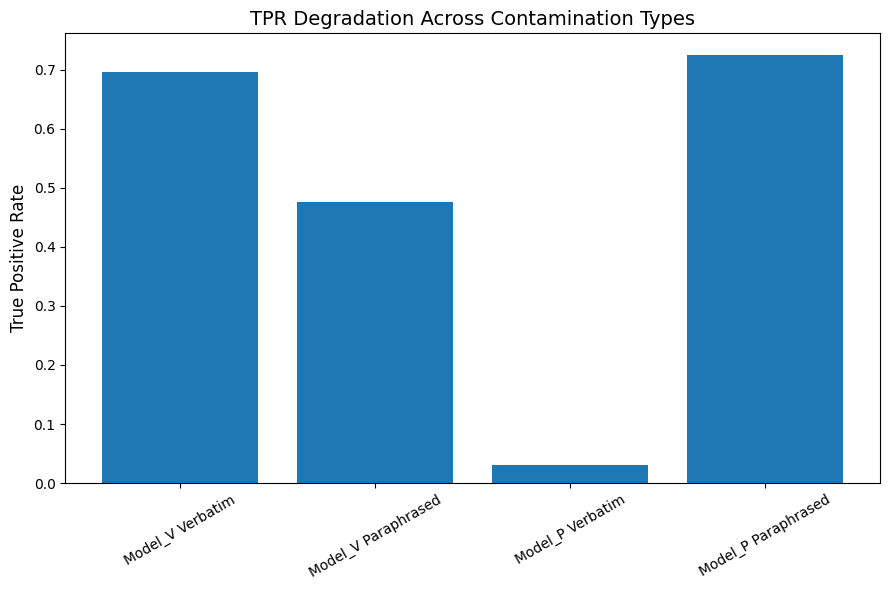

In [3]:
plt.figure(figsize=(9,6))

plt.bar(conditions, tpr_values)

plt.ylabel("True Positive Rate", fontsize=12)
plt.title("TPR Degradation Across Contamination Types", fontsize=14)

plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig("figure2_tpr_degradation.png", dpi=300)

plt.show()